XGB classifier that uses input features decided via Mutual Information Scores

In [6]:
#XGB classifier on the top 15 features selected by feature importance from XGB_initial
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc
import sys
sys.path.append('../..')  # goes up from XGB_Classifier/ to Electron_Project/
from Modules.Utils import fast_preprocess_data  
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.metrics import f1_score



In [7]:
x_train, x_test, y_train, y_test = fast_preprocess_data('/Users/prometheus/Documents/Python/Electron_Project/Data/AppML_InitialProject_train.h5', 'p_Truth_isElectron', test_size=0.2)

Dataset loaded from /Users/prometheus/Documents/Python/Electron_Project/Data/AppML_InitialProject_train.h5 with shape (180000, 140)
Target variable 'p_Truth_isElectron' has 2 unique values and distribution:
p_Truth_isElectron
0    0.79
1    0.21
Name: proportion, dtype: float64
No missing values detected in the dataset.
Dropped 44 highly correlated features


In [8]:
#fit the model
parameters = {
    'n_estimators': 10000,
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'reg_lambda': 1,
    'eval_metric': 'logloss',
    'early_stopping_rounds': 10
}

model = XGBClassifier(**parameters)
model.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_test, y_test)])

print("Best iteration:", model.get_booster().best_iteration)

[0]	validation_0-logloss:0.45323	validation_1-logloss:0.45096
[1]	validation_0-logloss:0.41209	validation_1-logloss:0.40989
[2]	validation_0-logloss:0.38115	validation_1-logloss:0.37902
[3]	validation_0-logloss:0.35660	validation_1-logloss:0.35449
[4]	validation_0-logloss:0.33558	validation_1-logloss:0.33348
[5]	validation_0-logloss:0.31803	validation_1-logloss:0.31602
[6]	validation_0-logloss:0.30315	validation_1-logloss:0.30125
[7]	validation_0-logloss:0.29037	validation_1-logloss:0.28855
[8]	validation_0-logloss:0.27924	validation_1-logloss:0.27741
[9]	validation_0-logloss:0.26988	validation_1-logloss:0.26802
[10]	validation_0-logloss:0.26127	validation_1-logloss:0.25943
[11]	validation_0-logloss:0.25315	validation_1-logloss:0.25143
[12]	validation_0-logloss:0.24588	validation_1-logloss:0.24426
[13]	validation_0-logloss:0.23943	validation_1-logloss:0.23781
[14]	validation_0-logloss:0.23424	validation_1-logloss:0.23258
[15]	validation_0-logloss:0.22930	validation_1-logloss:0.22776
[1

In [9]:
#evaluate the model
y_pred = model.predict(x_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     28492
           1       0.94      0.77      0.85      7508

    accuracy                           0.94     36000
   macro avg       0.94      0.88      0.91     36000
weighted avg       0.94      0.94      0.94     36000

Confusion Matrix:
[[28134   358]
 [ 1711  5797]]
Accuracy Score: 0.9425277777777777


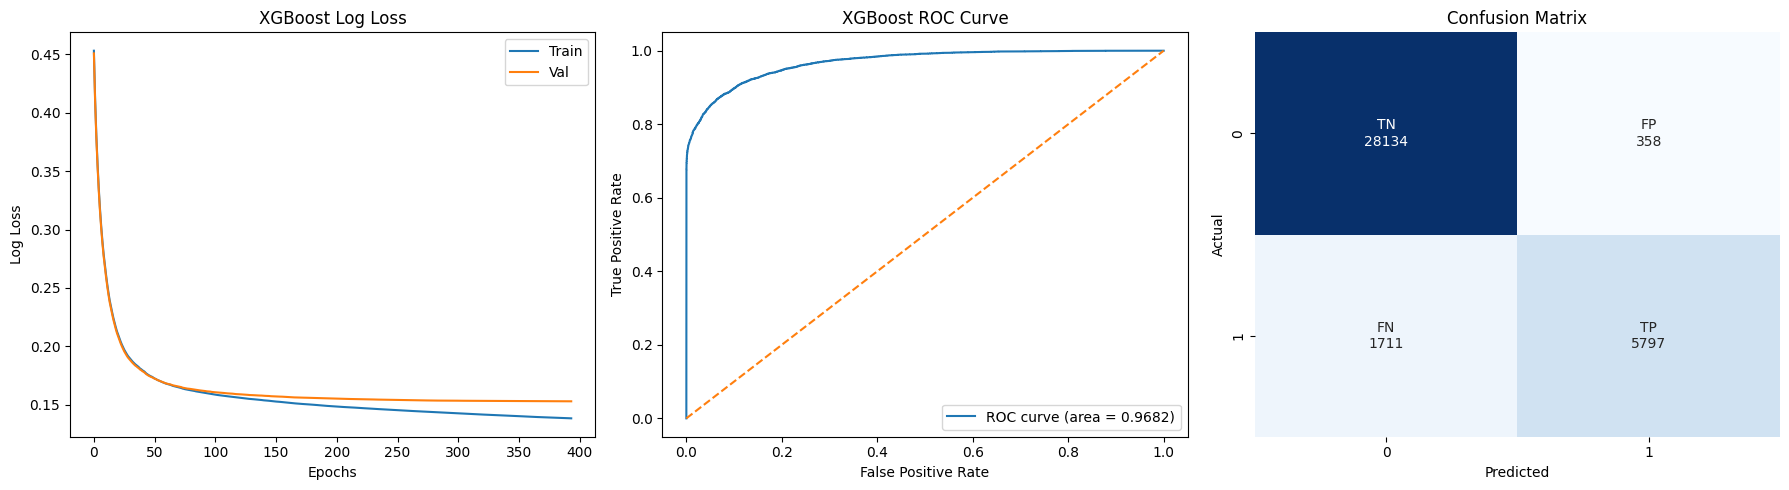

In [10]:
#plot training loss, roc curve and confusion matrix with tp fp tn fn labels
results = model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
plt.plot(x_axis, results['validation_1']['logloss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss')
plt.legend()

y_prob = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend()

cm = confusion_matrix(y_test, y_pred)
labels = [['TN', 'FP'], ['FN', 'TP']]
annot = [[f"{l}\n{v}" for l, v in zip(row_l, row_v)] for row_l, row_v in zip(labels, cm)]
plt.subplot(1, 3, 3)
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()


In [ ]:
#use optuna to optimize hyperparameters, with early stopping and pruning
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0),
        'eval_metric': 'logloss',
        'early_stopping_rounds': 10
    }
    
    model = XGBClassifier(**params)
    model.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_test, y_test)], verbose=False)
    
    y_pred = model.predict(x_test)
    return f1_score(y_test, y_pred)

#evaluate the best hyperparameters found by optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=500, n_jobs=-1)

print("Best trial:")
trial = study.best_trial
print("  Value: ", trial.value)
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2026-05-07 15:44:40,380] A new study created in memory with name: no-name-a0e2ffc9-fff5-498f-b978-e9077dee04cd
[I 2026-05-07 15:44:42,286] Trial 8 finished with value: 0.8349218452154022 and parameters: {'n_estimators': 112, 'max_depth': 3, 'learning_rate': 0.02947674559109819, 'subsample': 0.5001335661493322, 'reg_lambda': 2.32168955524006}. Best is trial 8 with value: 0.8349218452154022.
[I 2026-05-07 15:44:42,844] Trial 4 finished with value: 0.8463398549131678 and parameters: {'n_estimators': 462, 'max_depth': 9, 'learning_rate': 0.17612736425884684, 'subsample': 0.7797903676072072, 'reg_lambda': 1.171513613612442}. Best is trial 4 with value: 0.8463398549131678.
[I 2026-05-07 15:44:42,973] Trial 0 finished with value: 0.8488609813084113 and parameters: {'n_estimators': 661, 'max_depth': 8, 'learning_rate': 0.1962155395377504, 'subsample': 0.6631727306046891, 'reg_lambda': 6.114246254024645}. Best is trial 0 with value: 0.8488609813084113.
[I 2026-05-07 15:44:43,299] Trial 3 fin

In [ ]:
#use best hyperparameters to fit the model and evaluate again
best_params = trial.params
best_params['eval_metric'] = 'logloss'
best_params['early_stopping_rounds'] = 10
model = XGBClassifier(**best_params)
model.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_test, y_test)], verbose=False)

print("Best iteration:", model.get_booster().best_iteration)
#evaluate the model
y_pred = model.predict(x_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Best iteration: 772
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     28458
           1       0.95      0.77      0.85      7542

    accuracy                           0.94     36000
   macro avg       0.95      0.88      0.91     36000
weighted avg       0.94      0.94      0.94     36000

Confusion Matrix:
[[28172   286]
 [ 1745  5797]]
Accuracy Score: 0.9435833333333333


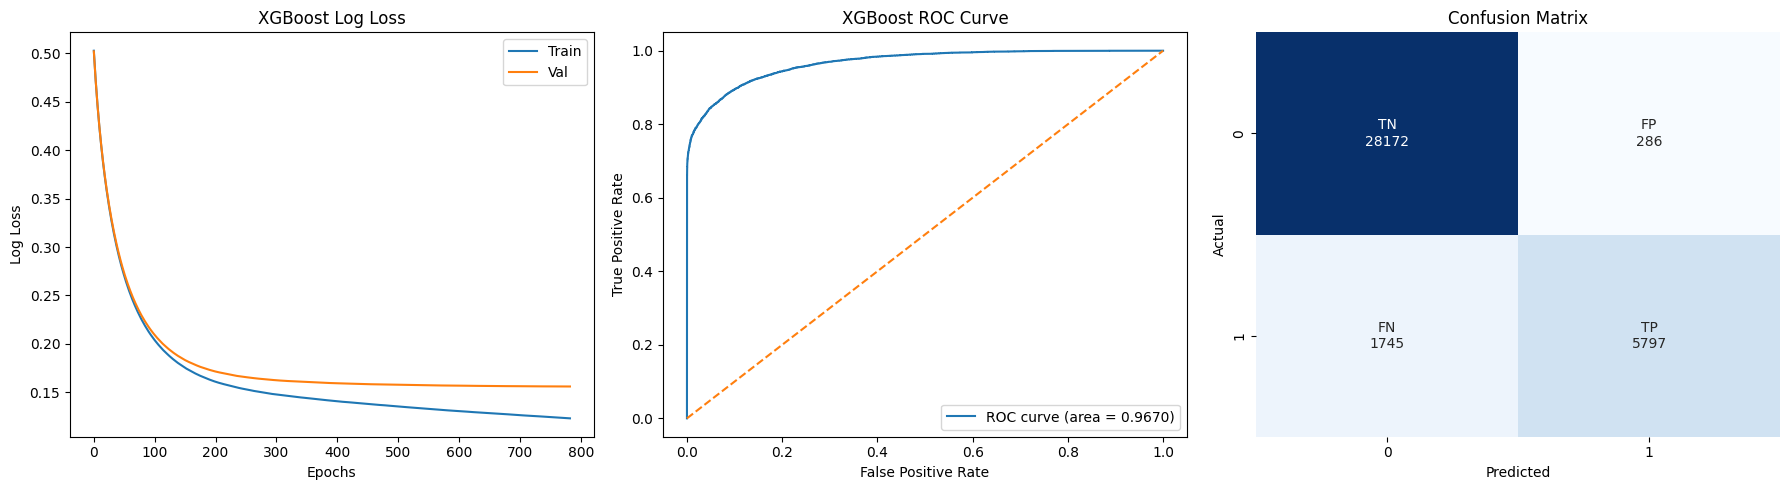

In [ ]:
#plot training loss, roc curve and confusion matrix with tp fp tn fn labels
results = model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
plt.plot(x_axis, results['validation_1']['logloss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss')
plt.legend()

y_prob = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend()

cm = confusion_matrix(y_test, y_pred)
labels = [['TN', 'FP'], ['FN', 'TP']]
annot = [[f"{l}\n{v}" for l, v in zip(row_l, row_v)] for row_l, row_v in zip(labels, cm)]
plt.subplot(1, 3, 3)
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()
